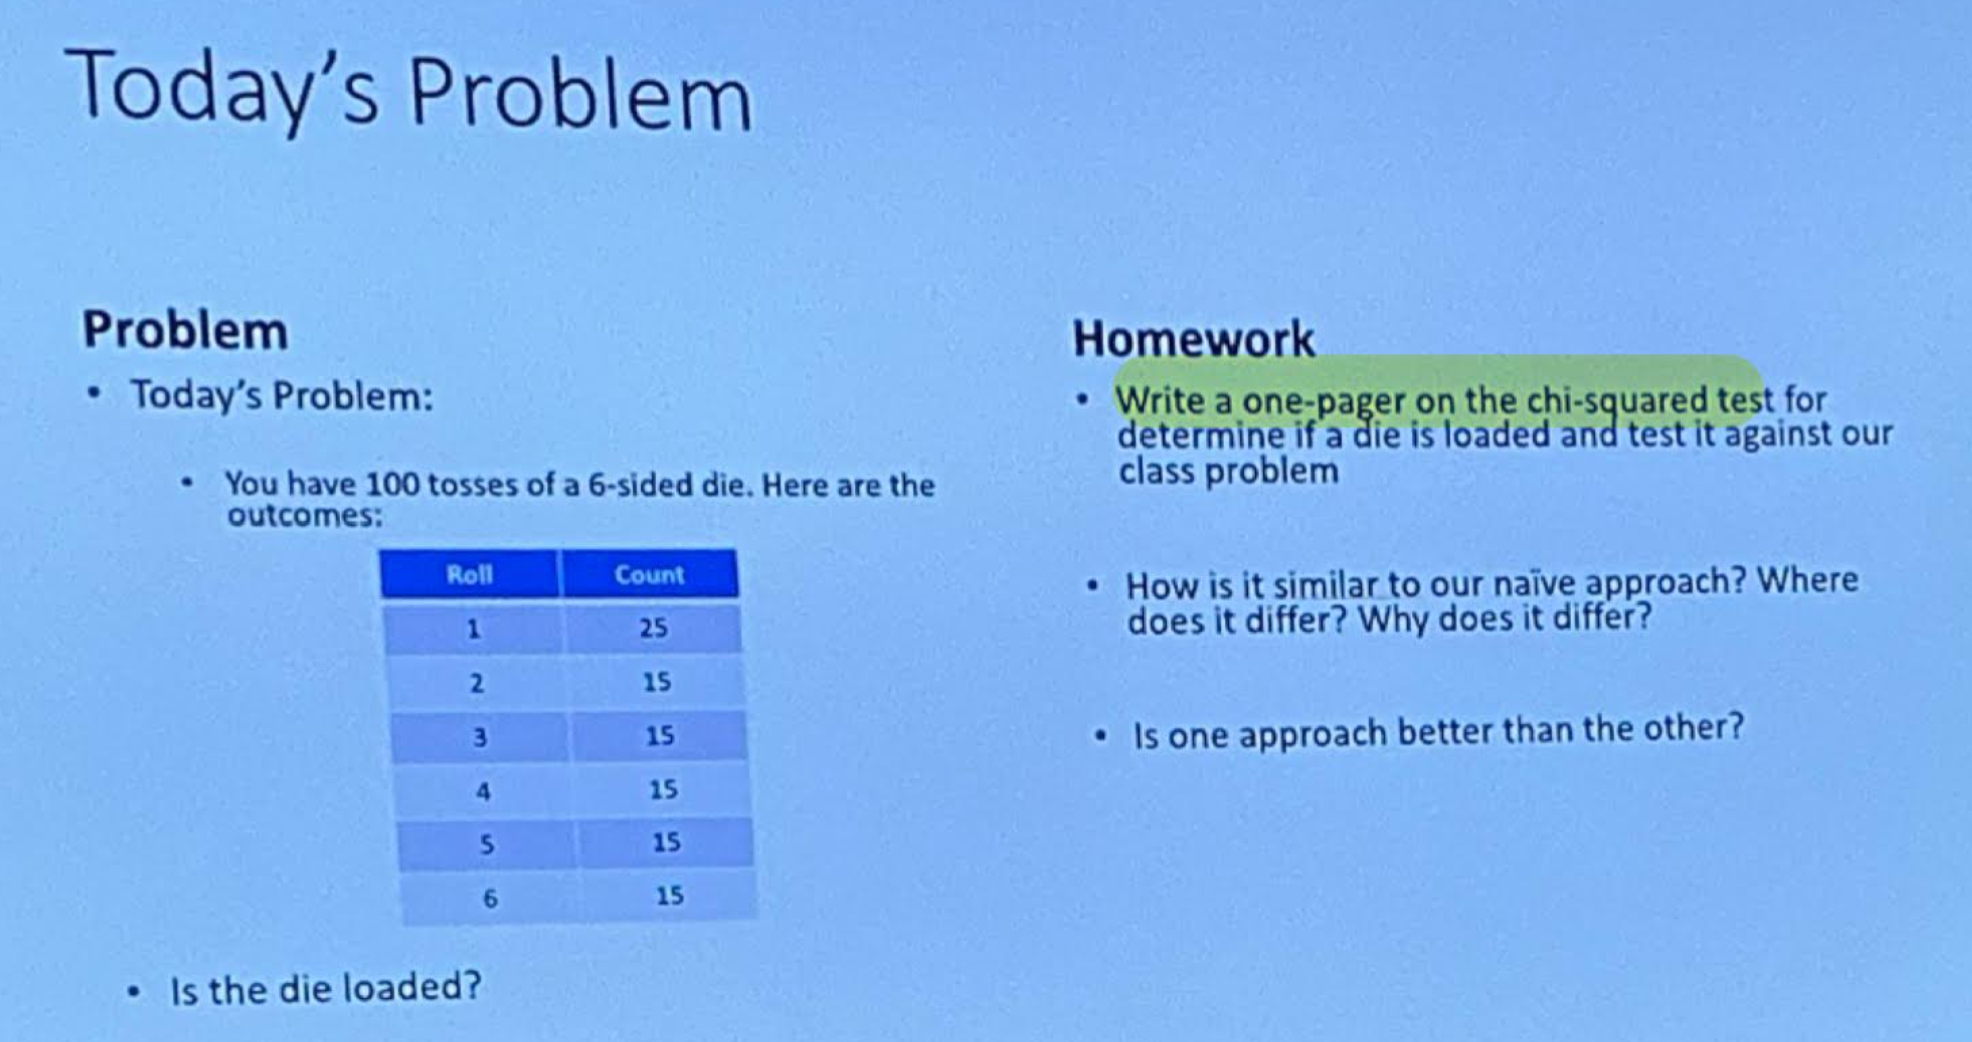

### Method1: Naive method
### Method2: Chi-squared test
### Method2: Binomial Distribution

#### In this homework, I tested if the dice is fair with 3 approaches:
* Simulation, the dice is loaded, P(roll x=1 25 times| The Dice is fair) =  0.02117
* Chi^2 test, could reject the hypothesis that the dice is fair.
* Binomial distribution, P(roll x=1 25 times| The Dice is fair) = 0.02170337873393608, value close to the simulation result.


In [51]:
import random
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import chi2
import numpy as np
import math

### 1. Naive Method
Use simulation to do 10000 trails, and use t test to see if the head =1 data series has average value = 25 or not

In [46]:
class check_dice_fair:
    def __init__(self, sides , n_trail , dice_run , test_side , realized_val, sig_level ):
        self.sides = sides
        self.cdf_lst = [i/6 for i in range(sides)] +[1]
        self.n_trail = n_trail
        self.dice_run = dice_run
        self.test_side = test_side
        self.realized_val = realized_val
        self.dice_summary_stat = self.dice_simulation()
        self.sig_level = sig_level
        

    def check_dice_class(self, val, cdf_l):
        dice_class = 0
        for k in range(len(cdf_l)):
            if k < len(cdf_l)-1:
                lower_bnd = cdf_l[k]
                upper_bnd = cdf_l[k+1]
                if (val> lower_bnd) & (val<= upper_bnd):
                    dice_class = k + 1
                    #print(dice_class, val)
        return dice_class  

    def dice_simulation(self):
        dice_class_summary_single_trail_lst = []
        for trail in range(self.n_trail):
            ran_lst = [random.random() for i in range(self.dice_run)]
            dice_class_lst = []
            for val in ran_lst:
                dice_class = self.check_dice_class(val, self.cdf_lst)
                dice_class_lst.append(dice_class)
            
            dice_class_summary_single_trail = pd.DataFrame({
                'random_val': ran_lst,
                'dice_class': dice_class_lst,
            })
            dice_class_summary_single_trail['trail'] = trail
            dice_class_summary_single_trail_lst.append(dice_class_summary_single_trail)
        dice_summary = pd.concat(dice_class_summary_single_trail_lst).reset_index(drop = True)
        dice_summary = dice_summary.sort_values(by = ['trail', 'random_val']).reset_index(drop = True)
        dice_summary_stat = pd.DataFrame( dice_summary.groupby(['trail','dice_class']).size() ).reset_index().rename(columns={0: "count"})

        return dice_summary_stat

    def draw_boxplot_notch(self):
        plt.boxplot(self.dice_summary_stat[self.dice_summary_stat['dice_class'] == 1]['count'], vert=True, patch_artist=True, notch=True)  # notch=True draws "notch"
        plt.ylabel('Number of "1"s in 100 rolls')
        plt.title('Boxplot of 10,000 simulated dice experiments')
        plt.show()
    
    def t_test(self):
        cnt_in_1 = self.dice_summary_stat[self.dice_summary_stat['dice_class'] == self.test_side]['count']
        t_stat, p_val = stats.ttest_1samp( cnt_in_1, self.realized_val)
        
        if p_val < 0.05:
            print('This dice is not fair dice!!!!!!')
        else:
            print('Could not prove this is a unfair dice.')

This dice is not fair dice!!!!!!


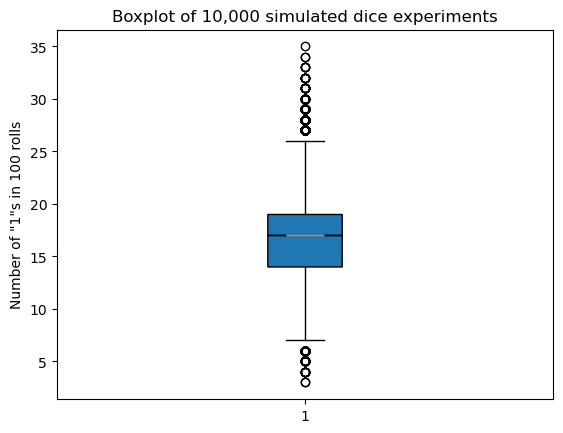

In [6]:
check_fairness =check_dice_fair(6, 100000, 100, 1, 25, 0.05)
check_fairness.t_test()
check_fairness.draw_boxplot_notch()

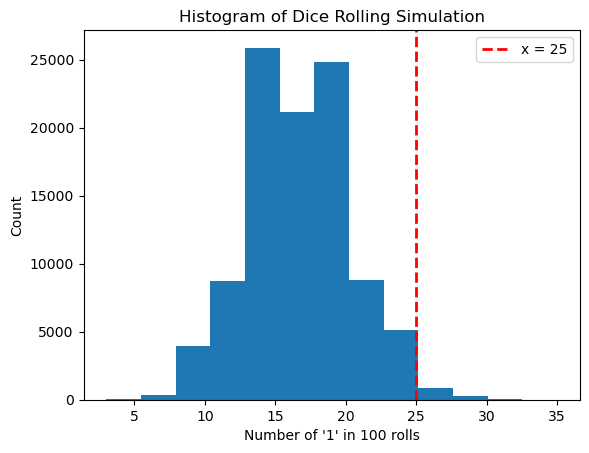

P(dice is fair & has 1 more than 25 times) = 0.02117
From the simulation result, the probability of the rolled dice is fair as well as has 25 count with side = '1' is small.


In [47]:
simulate_dice_output = check_fairness.dice_summary_stat
x = simulate_dice_output[simulate_dice_output['dice_class'] == 1]['count']
n_bin = round(np.log(len(x))+1) ## Sturge's Rule
plt.hist(x, bins = n_bin )
plt.axvline(25, color="red", linestyle="--", linewidth=2, label="x = 25")

plt.xlabel("Number of '1' in 100 rolls")             
plt.ylabel("Count")          
plt.title(f"Histogram of Dice Rolling Simulation") 
plt.legend()
plt.show() 
print('P(dice is fair & has 1 more than 25 times) =', str(simulate_dice_output[(simulate_dice_output['dice_class'] == 1) & (simulate_dice_output['count'] >=25) ].shape[0]/len(x))  )
print("From the simulation result, the probability of the rolled dice is fair as well as has 25 count with side = '1' is small.")

### 2. Chi^2 Distribution
Expect equal output and has realized value, which follow Chi^2 distribution with degree of freedom = n-1=6-1=5

In [48]:
data = pd.DataFrame({ "Expect": [100/6, ]*6,
                      "Realized": [25, 15, 15,15,15,15]})
alpha = 0.05
df = 5
cv = chi2.ppf(1 - alpha, df)

In [50]:
data['diff'] = (data['Realized'] - data['Expect'])**2
data['norm'] = data['diff']/data['Expect']
data['norm'].sum()
if data['norm'].sum()> cv:
    print('With the Chi^2 Test, reject Ha, this dice is unfair dice')
else:
    print('With the Chi^2 Test, fail to reject Ha in 5% significance level, no strong evidence to show this dice is unfair dice.')


With the Chi^2 Test, fail to reject Ha in 5% significance level, no strong evidence to show this dice is unfair dice.


### 3. Binomial Distribution
<br> Bernoulli: Suppose it is 1 roll, dice value = 1 & p = 1/6; dice value = 2 to 6 & p = 5/6 
<br> Binomial: roll 100 times, fair distribution is Binomial(100, 1/6)

$$
 P(X \geq   k) = \sum_{i=k}^{n} \binom{n}{i} p^i (1-p)^{n-i}
$$
* k = 25
* n = 100
* p = 1/6

In [66]:
p = 1/6
sum_lst = []
for i in  list(range(25, 101)):
    comb =  math.comb(100, i)
    pi =  ((p )** i)
    pj =  ((1-p)**(100-i))
    p1 = comb*pi*pj
    sum_lst.append(p1)
prob_fair_dice = sum(sum_lst)
print('P(roll x=1 25 times| The Dice is fair) =', prob_fair_dice)

P(roll x=1 25 times| The Dice is fair) = 0.02170337873393608
